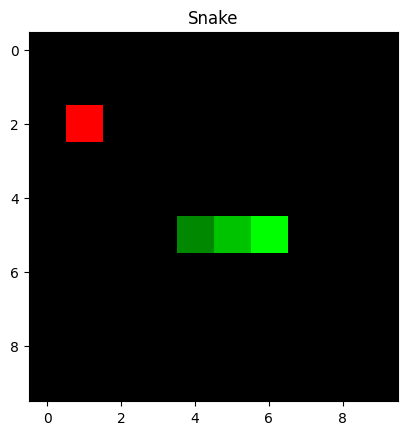

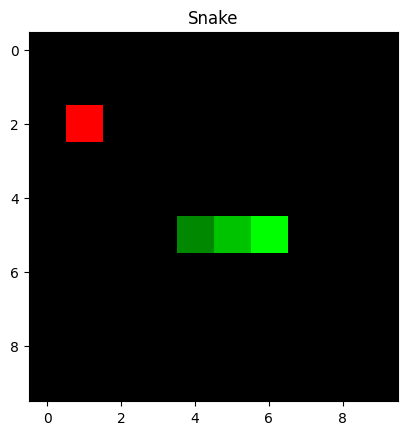

In [1]:
import gymnasium as gym
import register_env  # this runs the register() call

env = gym.make("Snake-v0", render_mode='matplotlib')
obs, info = env.reset()
env.render()

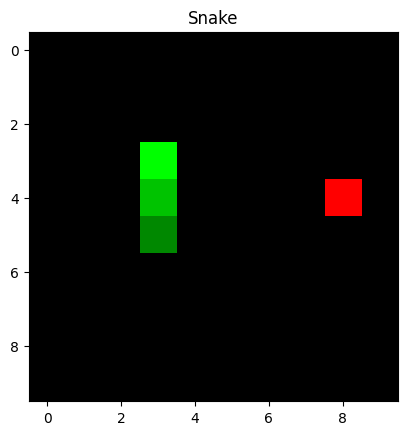

In [2]:
for i in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    if terminated or truncated:
        env.reset()

In [3]:
import gymnasium as gym
from stable_baselines3 import PPO

env = gym.make("Snake-v0", render_mode='matplotlib')  # or your own env instance

# Initialize the PPO model
model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
)

# Train the model
model.learn(total_timesteps=10_000)

# Save the model
model.save("ppo_snake")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 17.2     |
|    ep_rew_mean     | -1.06    |
| time/              |          |
|    fps             | 851      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 20.7        |
|    ep_rew_mean          | -1.08       |
| time/                   |             |
|    fps                  | 588         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011150714 |
|    clip_fraction        | 0.0889      |
|    clip_range           | 0.2         |
|    entropy_loss   

In [3]:
from stable_baselines3 import PPO
import gymnasium as gym
import register_env

model = PPO.load("ppo_snake", env=env)

obs, info = env.reset()
for _ in range(500):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    env.render()
    if done or truncated:
        obs, info = env.reset()

ValueError: Name tf.RaggedTensorSpec has already been registered for class tensorflow.python.ops.ragged.ragged_tensor.RaggedTensorSpec.